In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
# Load data
with open('lidl_clean.json') as f:
    data = json.load(f)

# Build receipts dataframe
receipts = pd.DataFrame([{
    'date': r['date'],
    'store': r['store'],
    'total': r['total'],
    'num_items': len(r['items'])
} for r in data])

receipts['date'] = pd.to_datetime(receipts['date'])
receipts['month'] = receipts['date'].dt.to_period('M')

print(f"Receipts: {len(receipts)}")
print(f"Date range: {receipts['date'].min().date()} to {receipts['date'].max().date()}")
print(f"Total spent: €{receipts['total'].sum():.2f}")
print(f"Avg basket: €{receipts['total'].mean():.2f}")
print(f"\nTop stores:")
print(receipts['store'].value_counts().head())

Receipts: 143
Date range: 2024-04-11 to 2026-04-01
Total spent: €1891.01
Avg basket: €13.22

Top stores:
store
Berlin-Lichtenberg-HSH    142
Lichtenberg                 1
Name: count, dtype: int64


In [3]:
items_df = pd.DataFrame([
    {
        'date': r['date'],
        'store': r['store'],
        'name': i['name'],
        'quantity': i['quantity'],
        'unit_price': i['unit_price'],
        'total_price': i['total_price'],
        'tax_type': i['tax_type'],
    }
    for r in data for i in r['items']
])

items_df['date'] = pd.to_datetime(items_df['date'])
items_df['month'] = items_df['date'].dt.to_period('M')

print(f"Total rows: {len(items_df)}")
print(f"Columns: {list(items_df.columns)}")
items_df.head(20)


Total rows: 1084
Columns: ['date', 'store', 'name', 'quantity', 'unit_price', 'total_price', 'tax_type', 'month']


,date,store,name,quantity,unit_price,total_price,tax_type,month
0,2024-04-11,Berlin-Lichtenberg-HSH,Clementinen,1.000,2.19,2.19,A,2024-04
1,2024-04-11,Berlin-Lichtenberg-HSH,Dattelcherrytomaten,1.000,2.39,2.39,A,2024-04
2,2024-04-11,Berlin-Lichtenberg-HSH,Tortelloni Fleisch,1.000,2.99,2.99,A,2024-04
3,2024-04-11,Berlin-Lichtenberg-HSH,Royal Hähnchenbrust,1.000,1.99,1.99,A,2024-04
4,2024-04-11,Berlin-Lichtenberg-HSH,"H-Milch1,5% HF3",1.000,0.95,0.95,A,2024-04
5,2024-04-11,Berlin-Lichtenberg-HSH,Regional.Eier aus BB,1.000,1.89,1.89,A,2024-04
6,2024-04-11,Berlin-Lichtenberg-HSH,Buttercr.Nuss-N,2.000,0.69,1.38,A,2024-04
7,2024-04-17,Berlin-Lichtenberg-HSH,Zwiebeln rot,1.000,2.29,2.29,A,2024-04
8,2024-04-17,Berlin-Lichtenberg-HSH,Paprika rot,1.000,2.89,2.89,A,2024-04
9,2024-04-17,Berlin-Lichtenberg-HSH,Kartoffeln,1.000,2.49,2.49,A,2024-04


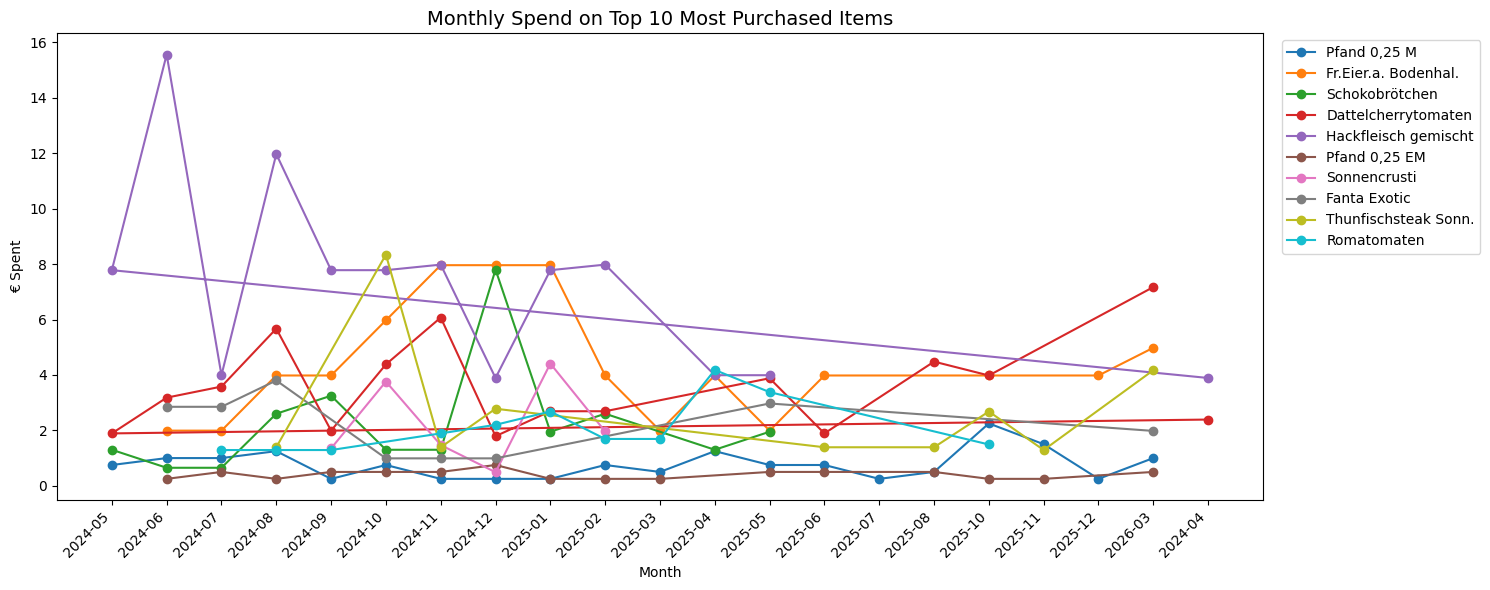

name,Dattelcherrytomaten,Fanta Exotic,Fr.Eier.a. Bodenhal.,Hackfleisch gemischt,"Pfand 0,25 EM","Pfand 0,25 M",Romatomaten,Schokobrötchen,Sonnencrusti,Thunfischsteak Sonn.
month_str,,,,,,,,,,
2024-04,2.39,0.00,0.00,3.89,0.00,0.00,0.00,0.00,0.00,0.00
2024-05,1.89,0.00,0.00,7.78,0.00,0.75,0.00,1.30,0.00,0.00
2024-06,3.18,2.85,1.99,15.56,0.25,1.00,0.00,0.65,0.00,0.00
2024-07,3.58,2.85,1.99,3.99,0.50,1.00,1.29,0.65,0.00,0.00
2024-08,5.67,3.80,3.98,11.97,0.25,1.25,1.29,2.60,0.00,1.39
2024-09,1.99,0.00,3.98,7.78,0.50,0.25,1.29,3.25,1.35,0.00
2024-10,4.38,0.99,5.97,7.78,0.50,0.75,0.00,1.30,3.76,8.34
2024-11,6.07,0.99,7.96,7.98,0.50,0.25,1.89,1.30,1.47,1.39
2024-12,1.79,0.99,7.96,3.89,0.75,0.25,2.20,7.80,0.49,2.78


In [7]:
# Get top 10 most purchased items
top_10_names = (
    items_df.groupby('name')['quantity']
    .count()
    .sort_values(ascending=False)
    .head(10)
    .index.tolist()
)

# Filter to only those items
top_items_monthly = items_df[items_df['name'].isin(top_10_names)].copy()

# Group by month and item name
monthly_items = (
    top_items_monthly
    .groupby(['month', 'name'])['total_price']
    .sum()
    .reset_index()
    .sort_values('month')
)

monthly_items['month_str'] = monthly_items['month'].astype(str)
months_ordered = sorted(monthly_items['month_str'].unique().tolist())

# Plot
fig, ax = plt.subplots(figsize=(15, 6))

for name in top_10_names:
    subset = monthly_items[monthly_items['name'] == name].sort_values('month')
    ax.plot(subset['month_str'], subset['total_price'], marker='o', label=name)

ax.set_title('Monthly Spend on Top 10 Most Purchased Items', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('€ Spent')
ax.set_xticks(months_ordered)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Table sorted by month asc
pivot = (
    monthly_items
    .pivot(index='month_str', columns='name', values='total_price')
    .fillna(0)
    .round(2)
    .loc[months_ordered]  # force correct row order
)
pivot

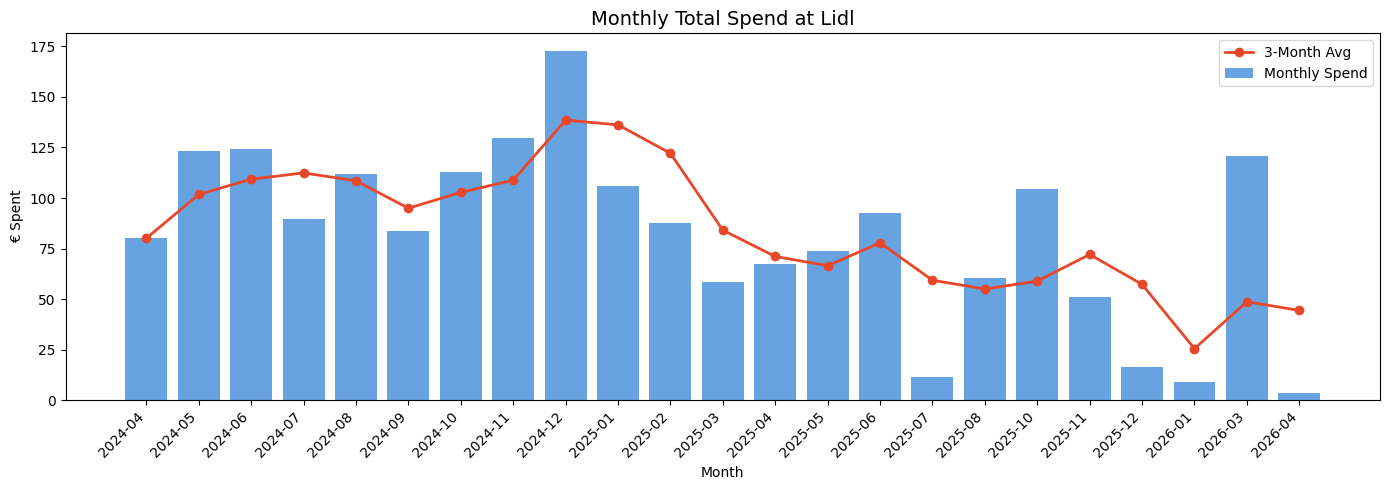

month_str  total  rolling_avg
  2024-04  80.07    80.070000
  2024-05 123.46   101.765000
  2024-06 124.36   109.296667
  2024-07  89.46   112.426667
  2024-08 111.68   108.500000
  2024-09  83.69    94.943333
  2024-10 113.02   102.796667
  2024-11 129.71   108.806667
  2024-12 172.85   138.526667
  2025-01 106.05   136.203333
  2025-02  87.49   122.130000
  2025-03  58.63    84.056667
  2025-04  67.12    71.080000
  2025-05  73.77    66.506667
  2025-06  92.56    77.816667
  2025-07  11.60    59.310000
  2025-08  60.65    54.936667
  2025-10 104.42    58.890000
  2025-11  51.15    72.073333
  2025-12  16.16    57.243333
  2026-01   9.04    25.450000
  2026-03 120.78    48.660000
  2026-04   3.29    44.370000


In [10]:
monthly_spend = (
    receipts.groupby('month')['total']
    .sum()
    .reset_index()
    .sort_values('month')
)
monthly_spend['month_str'] = monthly_spend['month'].astype(str)

# Add 3-month rolling average
monthly_spend['rolling_avg'] = monthly_spend['total'].rolling(3, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(monthly_spend['month_str'], monthly_spend['total'], color='#0066cc', alpha=0.6, label='Monthly Spend')
ax.plot(monthly_spend['month_str'], monthly_spend['rolling_avg'], color='#e8472a', linewidth=2, marker='o', label='3-Month Avg')
ax.set_title('Monthly Total Spend at Lidl', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('€ Spent')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(monthly_spend[['month_str', 'total', 'rolling_avg']].to_string(index=False))

=== Price Increases ===
                      price_2024  price_2025_26  change_pct
name                                                       
Grana Padano gerieb.    2.590000          3.290        27.0
Barilla Sauce Arrab.    2.590000          3.190        23.2
Peperoni Mix            1.650000          1.990        20.6
Dattelcherrytomaten     1.856667          2.190        18.0
Hähnchenoberkeule       2.990000          3.490        16.7
Romatomaten             1.290000          1.490        15.5
fit Spülmittel Orig.    1.950000          2.150        10.3
Clementinen             2.190000          2.390         9.1
Fr.Eier.a. Bodenhal.    1.990000          2.115         6.3
Griech. Fetakäse        2.190000          2.290         4.6

=== Price Decreases ===
                      price_2024  price_2025_26  change_pct
name                                                       
Thunfischsteak Sonn.    1.390000       1.365000        -1.8
Penne Rigate            0.790000       0.740000    

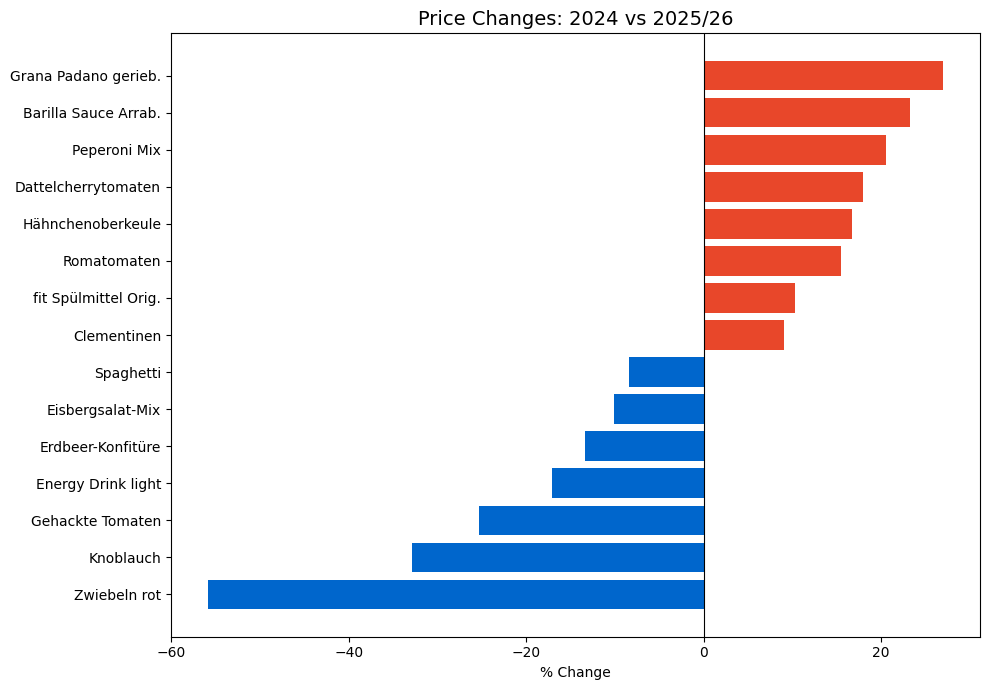

In [11]:
# Find items purchased in both early 2024 and 2025/2026
items_df['year'] = items_df['date'].dt.year

early = items_df[items_df['month'].astype(str) <= '2024-08'].groupby('name')['unit_price'].mean()
late  = items_df[items_df['month'].astype(str) >= '2025-06'].groupby('name')['unit_price'].mean()

inflation = pd.DataFrame({'price_2024': early, 'price_2025_26': late}).dropna()
inflation['change_pct'] = ((inflation['price_2025_26'] - inflation['price_2024']) / inflation['price_2024'] * 100).round(1)
inflation = inflation[inflation['price_2024'] > 0].sort_values('change_pct', ascending=False)

print("=== Price Increases ===")
print(inflation.head(10).to_string())
print("\n=== Price Decreases ===")
print(inflation.tail(10).to_string())

# Plot top 15 changes
top_changes = pd.concat([inflation.head(8), inflation.tail(7)]).sort_values('change_pct')
colors = ['#0066cc' if x < 0 else '#e8472a' for x in top_changes['change_pct']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_changes.index, top_changes['change_pct'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Price Changes: 2024 vs 2025/26', fontsize=14)
ax.set_xlabel('% Change')
plt.tight_layout()
plt.show()

Total months in dataset: 23

Top 20 most loyal items:
                name  months_purchased  loyalty_score
        Pfand 0,25 M                20           87.0
Fr.Eier.a. Bodenhal.                16           69.6
       Pfand 0,25 EM                16           69.6
 Dattelcherrytomaten                16           69.6
Hackfleisch gemischt                13           56.5
      Schokobrötchen                12           52.2
        Basmati Reis                11           47.8
        Peperoni Mix                11           47.8
         Romatomaten                11           47.8
           Spaghetti                10           43.5
Thunfischsteak Sonn.                 9           39.1
        Zwiebeln rot                 9           39.1
Blattsalat-Rohk.-Mix                 8           34.8
    Eisbergsalat-Mix                 8           34.8
        H-Milch 1,5%                 8           34.8
    Gehackte Tomaten                 8           34.8
        Schoko Donut        

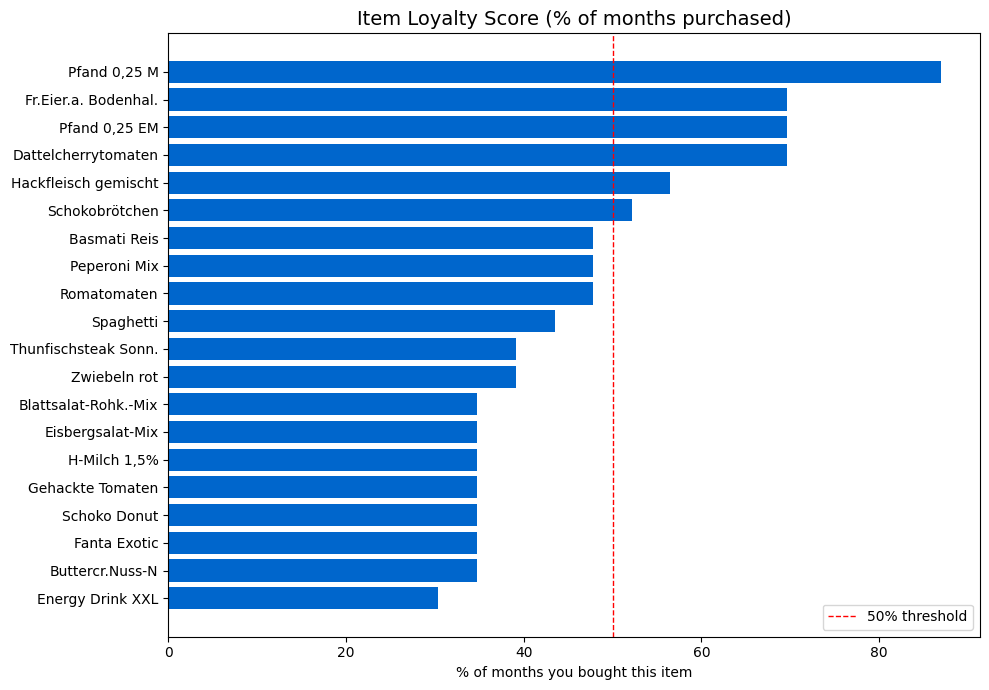

In [12]:
# Total months in dataset
total_months = monthly_spend['month_str'].nunique()

# Count how many distinct months each item appears in
loyalty = (
    items_df.groupby('name')['month']
    .nunique()
    .reset_index()
    .rename(columns={'month': 'months_purchased'})
)
loyalty['loyalty_score'] = (loyalty['months_purchased'] / total_months * 100).round(1)
loyalty = loyalty.sort_values('loyalty_score', ascending=False)

print(f"Total months in dataset: {total_months}")
print("\nTop 20 most loyal items:")
print(loyalty.head(20).to_string(index=False))

# Plot top 20
top_loyal = loyalty.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top_loyal['name'], top_loyal['loyalty_score'], color='#0066cc')
ax.set_title('Item Loyalty Score (% of months purchased)', fontsize=14)
ax.set_xlabel('% of months you bought this item')
ax.axvline(50, color='red', linestyle='--', linewidth=1, label='50% threshold')
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()